# Proyecto RappiPlus: de datos a decisiones de negocio

**Introducción**


El objetivo de este proyecto es evaluar el desempeño del servicio **RappiPlus** para apoyar **decisiones de negocio basadas en datos**.

Se trabajan con múltiples datasets del negocio:

- **rappiplus_orders_raw.csv** → información de pedidos, precios, descuentos y revenue  
- **rappiplus_catalog.csv** → costos de productos, categorías y proveedores  
- **rappiplus_marketing_spend.csv** → inversión en marketing por canal y país  
- **events / users / user_activity (SQL)** → comportamiento del usuario dentro de la plataforma  
- **experiment_checkout_ui.csv** → resultados de un experimento A/B en el checkout  

El análisis sigue una lógica clara y progresiva:

1. 🔍 Evaluar si podemos confiar en los datos (calidad de datos en Python) 

2. 💰 Analizar si el negocio es rentable (revenue, costos y profit)  

3. 🛒 Entender dónde se pierden los usuarios (funnel de conversión)  

4. 🔁 Evaluar si los usuarios regresan (retención por cohortes)  

5. 🧪 Validar si los cambios generan impacto (test estadístico)  

6. 📊 Comunicar los resultados (dashboard en BI)  

A lo largo del proyecto, se transforman datos en insights para responder preguntas clave del negocio y proponer **recomendaciones accionables**.

---

## 🔹 Paso 1: Cargar y validar la calidad de los datos

---

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:** Familiarizarte con la estructura de los datasets del negocio antes de analizarlos.

**Instrucciones:**

- Importa las librerías necesarias
- Carga los archivos:
  - `rappiplus_orders_raw.csv`
  - `rappiplus_catalog.csv`
  - `rappiplus_marketing_spend.csv`
- Guarda los DataFrames en:
  - `orders`, `catalog`, `marketing`
- Explora cada dataset.

---

In [10]:
# Importamos librerías 
import pandas as pd
import numpy as np

In [11]:
# Cargamos los tres archivos
orders = pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/rappiplus_orders_raw.csv')
catalog = pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/rappiplus_catalog.csv')
marketing = pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/rappiplus_marketing_spend.csv')

In [12]:
# Explorando los DataFrames
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25100 entries, 0 to 25099
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_pedido           25100 non-null  object 
 1   id_usuario          25100 non-null  object 
 2   fecha_hora_pedido   25100 non-null  object 
 3   pais                24800 non-null  object 
 4   dispositivo         25080 non-null  object 
 5   fuente_referencia   25070 non-null  object 
 6   nombre_producto     25070 non-null  object 
 7   categoria_producto  25020 non-null  object 
 8   cantidad            25050 non-null  float64
 9   precio_unitario     25050 non-null  float64
 10  monto_descuento     25050 non-null  float64
 11  monto_total         25100 non-null  float64
dtypes: float64(4), object(8)
memory usage: 2.3+ MB


In [13]:
orders.head(10)

,id_pedido,id_usuario,fecha_hora_pedido,pais,dispositivo,fuente_referencia,nombre_producto,categoria_producto,cantidad,precio_unitario,monto_descuento,monto_total
0,order_0,user_6993,2025-05-22,Argentina,desktop,organic,Jacket-Winter-M,Moda,2.0,332.69,0.0,665.37
1,order_1,user_1329,2025-06-15,Mexico,desktop,paid_search,Tablet-Standard-64GB,Electronica,1.0,176.86,5.0,171.86
2,order_2,user_3194,2025-05-02,Argentina,desktop,social,Blender-XL-Red,Hogar,2.0,102.99,10.0,195.99
3,order_3,user_4510,2025-06-09,Colombia,mobile,social,Tablet-Standard-64GB,Electronica,1.0,257.87,15.0,242.87
4,order_4,user_5044,2025-03-30,Argentina,desktop,paid_search,Blender-XL-Red,Hogar,1.0,336.28,0.0,336.28
5,order_5,user_2792,2025-04-22,mexico,desktop,organic,Tablet-Standard-64GB,Electronica,1.0,179.34,0.0,179.34
6,order_6,user_2802,2025-03-15,Colombia,mobile,organic,Blender-XL-Red,Hogar,2.0,163.59,0.0,327.19
7,order_7,user_1083,2025-05-01,Mexico,desktop,organic,Tablet-Standard-64GB,Electronica,2.0,373.68,0.0,747.35
8,order_8,user_2352,2025-03-01,Argentina,desktop,paid_search,Laptop-Gaming-16GB,Electronica,2.0,477.27,5.0,949.54
9,order_9,user_7001,2025-05-31,Mexico,mobile,organic,Sneakers-Urban-42,Moda,1.0,339.30,5.0,334.30


In [14]:
catalog.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   nombre_producto     7 non-null      object 
 1   categoria_producto  7 non-null      object 
 2   costo_unitario      7 non-null      float64
 3   proveedor           7 non-null      object 
dtypes: float64(1), object(3)
memory usage: 352.0+ bytes


In [15]:
catalog.head(5)

,nombre_producto,categoria_producto,costo_unitario,proveedor
0,Laptop-Gaming-16GB,Electrónica,280.68,"Fuller, Pena and Myers"
1,Phone-Pro-128GB,Electrónica,10.12,King Ltd
2,Tablet-Standard-64GB,Electrónica,25.21,Bowers LLC
3,Blender-XL-Red,Hogar,176.64,Long-Reid
4,Vacuum-Pro-Black,Hogar,16.60,"Rivera, Carr and Finley"


In [16]:
marketing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1620 entries, 0 to 1619
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   fecha       1620 non-null   object 
 1   pais        1620 non-null   object 
 2   id_campaña  1620 non-null   object 
 3   canal       1519 non-null   object 
 4   gasto       1620 non-null   float64
dtypes: float64(1), object(4)
memory usage: 63.4+ KB


In [17]:
marketing.head(10)

,fecha,pais,id_campaña,canal,gasto
0,2025-01-01,Mexico,organic_Mexico,organic,2446.25
1,2025-01-01,Mexico,paid_search_Mexico,paid_search,2704.34
2,2025-01-01,Mexico,social_Mexico,social,2045.01
3,2025-01-01,Colombia,organic_Colombia,organic,2597.21
4,2025-01-01,Colombia,paid_search_Colombia,paid_search,1771.40
5,2025-01-01,Colombia,social_Colombia,social,833.38
6,2025-01-01,Argentina,organic_Argentina,organic,1365.62
7,2025-01-01,Argentina,paid_search_Argentina,paid_search,1282.65
8,2025-01-01,Argentina,social_Argentina,social,1534.69
9,2025-01-02,Mexico,organic_Mexico,organic,2537.38


### Revisión y calidad de datos

**🎯 Objetivo:** Detectar y corregir problemas en los datos que puedan afectar el análisis de revenue, costos y rentabilidad.

Se revisan los 3 datasets
- Validar y convertir fechas al formato correcto  
- Revisar variables numéricas (sin negativos o ceros inválidos)  
- Verificar consistencia de montos  
- Eliminar duplicados  
- Revisar variables categóricas 

---

## Tipo de Datos
Podemos observar que en el DF **orders** como en **marketing** tenemos dos tipos de datos incorrectos **'fecha_hora_pedido'** y **'fecha'** respectivamente.
Por lo que haremos la conversión de datos, dtype 'datetime'.

In [18]:
# Conversion de columnas
orders['fecha_hora_pedido'] = pd.to_datetime(orders['fecha_hora_pedido'], errors='coerce')
marketing['fecha'] = pd.to_datetime(marketing['fecha'], errors='coerce')

---

In [19]:
# Verificamos la conversión
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25100 entries, 0 to 25099
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   id_pedido           25100 non-null  object        
 1   id_usuario          25100 non-null  object        
 2   fecha_hora_pedido   25100 non-null  datetime64[ns]
 3   pais                24800 non-null  object        
 4   dispositivo         25080 non-null  object        
 5   fuente_referencia   25070 non-null  object        
 6   nombre_producto     25070 non-null  object        
 7   categoria_producto  25020 non-null  object        
 8   cantidad            25050 non-null  float64       
 9   precio_unitario     25050 non-null  float64       
 10  monto_descuento     25050 non-null  float64       
 11  monto_total         25100 non-null  float64       
dtypes: datetime64[ns](1), float64(4), object(7)
memory usage: 2.3+ MB


In [20]:
marketing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1620 entries, 0 to 1619
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   fecha       1620 non-null   datetime64[ns]
 1   pais        1620 non-null   object        
 2   id_campaña  1620 non-null   object        
 3   canal       1519 non-null   object        
 4   gasto       1620 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(3)
memory usage: 63.4+ KB


## Variables númericas

Para validar las variables númericas usamos .describe() para ver un resumen de los datasets.

In [21]:
orders.describe()

,cantidad,precio_unitario,monto_descuento,monto_total
count,25050.000000,25050.000000,25050.000000,2.510000e+04
mean,7.092735,259.305549,4.500798,2.072680e+03
std,296.277003,138.726461,5.223010,9.894995e+04
min,-2.000000,20.030000,0.000000,-4.926500e+02
25%,1.000000,138.377500,0.000000,1.805075e+02
50%,2.000000,258.715000,0.000000,3.417500e+02
75%,2.000000,380.332500,10.000000,5.185800e+02
max,20000.000000,499.960000,15.000000,8.840200e+06


In [22]:
marketing.describe()

,gasto
count,1620.00000
mean,1772.74292
std,734.43294
min,501.11000
25%,1128.03000
50%,1782.42500
75%,2420.68500
max,2999.36000


In [23]:
catalog.describe()

,costo_unitario
count,7.000000
mean,102.252857
std,111.011563
min,10.120000
25%,16.905000
50%,25.210000
75%,182.975000
max,280.680000


Podemos observar dos problemas los cuales nos darían una decisión de negocio distinta

En **cantidad** podemos observar valores negativos, lo que podría significar dos cosas, un error de captura o alguna devolución o cancelación registrada.
Por lo que debemos inspeccionar a detalle esas filas para comprender el contexto.

In [24]:
# Problema 1: cantidad con valores negativos en orders
orders[orders['cantidad'] < 0]

,id_pedido,id_usuario,fecha_hora_pedido,pais,dispositivo,fuente_referencia,nombre_producto,categoria_producto,cantidad,precio_unitario,monto_descuento,monto_total
266,order_266,user_7011,2025-03-13,NaN,desktop,paid_search,Phone-Pro-128GB,Electronica,-2.0,101.31,10.0,-192.62
267,order_267,user_1087,2025-05-07,NaN,desktop,social,Phone-Pro-128GB,Electronica,-1.0,43.50,5.0,-38.50
268,order_268,user_84,2025-02-19,NaN,desktop,organic,Phone-Pro-128GB,Electronica,-1.0,497.65,5.0,-492.65
269,order_269,user_3323,2025-05-25,NaN,desktop,paid_search,Phone-Pro-128GB,Electronica,-1.0,423.53,0.0,-423.53


Las 4 filas con cantidad negativa comparten dos características: no tienen país registrado (NaN) y son todas del mismo producto **(Phone-Pro-128GB)**. Esto sugiere que no son errores aleatorios de captura, sino posiblemente un problema puntual en el pipeline de datos para ese producto específico, reforzando la decisión de tratarlas como registros inválidos en vez de datos legítimos

In [25]:
# Problema 2: Cantidades exageradas en orders
print(orders['cantidad'].quantile([0.5, 0.9, 0.99, 0.999, 1.0]))  

0.500        2.0
0.900        2.0
0.990        2.0
0.999        2.0
1.000    20000.0
Name: cantidad, dtype: float64


Se observan valores exagerados (outliers) y que la mayoría de las compras son mucho menores lo que confirma que no son compras legítimas

In [26]:
filas_antes = len(orders)

orders = orders[(orders['cantidad'] > 0) & (orders['cantidad'] <= 100) | (orders['cantidad'].isnull())]

filas_despues = len(orders)
print(f"Filas eliminadas: {filas_antes - filas_despues}")

Filas eliminadas: 14


In [27]:
# Verificación post-limpieza
print("Negativos restantes:", (orders['cantidad'] < 0).sum())      # esperado: 0
print("Outliers restantes:", (orders['cantidad'] > 100).sum())     # esperado: 0
print("Nulos preservados:", orders['cantidad'].isnull().sum())     # esperado: 50

Negativos restantes: 0
Outliers restantes: 0
Nulos preservados: 50


## Justificación
**1. Eliminación de cantidades negativas (4 filas)**

"Se encontraron 4 pedidos con cantidad negativa (-1, -2), podrían ser un error de captura, pero al no contar con una columna que detalle si es un tipo de transacción distinta no se puede comprobar. Además las 4 filas son del mismo producto **(Phone-Pro-128GB)** y no cuentan con país registrado (NaN), al ser un pequeño porcentaje del DF se decidió eliminarlas para no afectar los datos."

**2. Eliminación de outliers extremos**

"Se detectaron pedidos con cantidades de 10,000 y 20,000 unidades, mientras que el percentil 99.9% de todo el dataset es de solo 2 unidades. No hay un valor intermedio entre 2 y 10,000 lo cual resulta raro e inusual, por lo que se asumió que son errores de captura y se decidió poner un limite de 100 unidades para poder descontar esos casos.

**3. Los 50 valores nulos NO se eliminan en este paso**

"Se decide no eliminar las filas con cantidad nula en este momento, porque se notó que esas mismas filas conservan un monto_total válido — es decir, aportan información completa para el análisis de revenue, aunque no sirvan para análisis que dependan del detalle de unidades o precio unitario. Se documenta esta decisión para tratarla de forma diferenciada según el tipo de análisis."

## Duplicados

In [28]:
# Paso 1: ver cuántas veces se repite cada id_pedido
conteo_ids = orders['id_pedido'].value_counts()
print(conteo_ids.head())

# Paso 2: quedarme solo con los ids que se repiten más de una vez
ids_repetidos = conteo_ids[conteo_ids > 1]
print("Cuántos ids están repetidos:", len(ids_repetidos))

# Paso 3: revisar algunos ejemplos para ver si los datos son iguales o distintos
lista_ids_repetidos = ids_repetidos.index.tolist()

for id_pedido in lista_ids_repetidos[:5]:  # reviso los primeros 5, no todos
    print(f"\nPedido: {id_pedido}")
    print(orders[orders['id_pedido'] == id_pedido])

# Paso 4: contar cuántas filas están duplicadas en TODO (todas las columnas iguales)
print("\nFilas duplicadas exactas:", orders.duplicated().sum())

order_17141    2
order_1735     2
order_22041    2
order_19635    2
order_22615    2
Name: id_pedido, dtype: int64
Cuántos ids están repetidos: 100

Pedido: order_17141
         id_pedido id_usuario fecha_hora_pedido      pais dispositivo  \
17141  order_17141  user_3970        2025-01-07  Colombia     desktop   
25063  order_17141  user_3970        2025-01-07  Colombia     desktop   

      fuente_referencia nombre_producto categoria_producto  cantidad  \
17141           organic  Blender-XL-Red              Hogar       2.0   
25063           organic  Blender-XL-Red              Hogar       2.0   

       precio_unitario  monto_descuento  monto_total  
17141           337.89              0.0       675.77  
25063           337.89              0.0       675.77  

Pedido: order_1735
        id_pedido id_usuario fecha_hora_pedido    pais dispositivo  \
1735   order_1735   user_728        2025-05-13  Mexico      mobile   
25078  order_1735   user_728        2025-05-13  Mexico      mobile   

In [29]:
filas_antes = len(orders)

orders = orders.drop_duplicates()

filas_despues = len(orders)
print(f"Filas eliminadas: {filas_antes - filas_despues}")  # debería dar 100

Filas eliminadas: 100


## Justificación
Al revisar los datos, se encontraron 100 filas que estaban repetidas. Antes de eliminarlas, se comprobó si tenían el mismo id_pedido pero con información distinta en las demás columnas (por ejemplo que el monto cambiara), ya que eso lo hubiera complicado. Pero al comparar, las 100 filas duplicadas son una copia de otra fila que ya existe. Por eso se decidió eliminar las copias usando drop_duplicates().

## Categoricas

In [30]:
# Inconsistencia de mayúsculas y minúsculas
orders['pais'] = orders['pais'].str.strip().str.title() # Quita espacios al inicio y final y pone la primer letra en mayúscula

In [31]:
# Inconsistencia en acentos
catalog['categoria_producto'] = catalog['categoria_producto'].str.replace('Electrónica', 'Electronica')

In [32]:
# Valores nulos
orders['pais'] = orders['pais'].fillna('Desconocido')

In [33]:
# Verificamos después de aplicar los cambios
print(orders['pais'].value_counts(dropna=False))
print(catalog['categoria_producto'].value_counts())

Mexico         8336
Colombia       8302
Argentina      8052
Desconocido     296
Name: pais, dtype: int64
Electronica    3
Moda           2
Hogar          2
Name: categoria_producto, dtype: int64


## Justificación
En la columna pais se notó que había las mismas 3 categorías escritas de dos formas distintas (por ejemplo "Mexico" y "mexico"), por lo que se homologaron en un mismo formato para que no se contaran como categorías diferentes. En categoria_producto en orders había inconsistencias de acento "Electronica", pero en catalog decía "Electrónica" con acento, lo que sería un problema al querer cruzar estos dos datasets, porque no hubiera encontrado coincidencias para esa categoría.

Pendiente para decidir después

Falta decidir qué hacer con los nulos de pais (296) y categoria_producto (80). No se ha hecho ninguna acción todavía más que remplazar "NaN" por "Desconocido", aun no se confirma si es mejor quitarlos, o esperar a ver si afectan el análisis que sigue.

In [34]:
# Consistencia de montos
# Calculo lo que "debería" dar el monto total
orders['monto_calculado'] = orders['cantidad'] * orders['precio_unitario'] - orders['monto_descuento']

# Diferencia entre monto_total que ya tenía el dataset
orders['diferencia'] = orders['monto_total'] - orders['monto_calculado']
orders['diferencia'] = orders['diferencia'].abs()

# Filas que tienen una diferencia grande (más de 1 peso)
filas_con_error = orders[orders['diferencia'] > 1]
print("Filas con error real:", len(filas_con_error))

Filas con error real: 0


Se verficó que el monto_total de cada pedido tenga sentido comparado con cantidad, precio y descuento, para saber si se puede confiar en el dato para el análisis de ingresos. Se calculó el esperado y se comparó con el monto_total real, y si la diferencia era mayor a 1 peso, se considera como un posible error. Al final no se encontró ninguna fila así, porque esos casos ya se habían corregido antes cuando se limpió la columna de cantidad negativa.

---
**📦 Exportación**: Una vez finalizada la limpieza, se exportan los datasets para utilizarlos en la última etapa del proyecto.

In [35]:
# exportar datasets
orders.to_csv('orders_clean.csv', index=False)
catalog.to_csv('catalog_clean.csv', index=False)
marketing.to_csv('marketing_clean.csv', index=False)

---

## 🔹 Paso 2: Analizar si el negocio es rentable

### 2.1 Cálculo de KPIs principales

**🎯 Objetivo:** Calcular los indicadores clave del negocio para evaluar ingresos, costos y rentabilidad.

Se usan los 3 datasets (`orders`, `catalog`, `marketing_spend`):

**📊 Parte 1: Rentabilidad del negocio**
- ¿Cuál es el ingreso total (revenue)? 
- ¿Cuál es el costo total? 
- ¿Cuánto se ha invertido en marketing? 
- ¿El negocio es rentable? (calcular profit)  

---

**📈 Parte 2: Comportamiento de ventas**
- ¿Cuál es el ticket promedio por orden? 
- ¿Cuál es la cantidad promedio de productos por orden? 
- ¿Cuál es el producto más vendido?
- ¿Cuánto se ha gastado en marketing por canal? 

In [36]:
# Parte 1: Rentabilidad del negocio
# Revenue
revenue_total = orders['monto_total'].sum()
print("Revenue Total: ", revenue_total)

Revenue Total:  9643909.559999999


In [37]:
# Costo total
orders_costo = orders.merge(catalog[['nombre_producto', 'costo_unitario']], on='nombre_producto', how='left')
orders_costo['costo_linea'] = orders_costo['cantidad'] * orders_costo['costo_unitario']
costo_total = orders_costo['costo_linea'].sum()
print("Costo Total: ", costo_total)

Costo Total:  3828869.01


In [38]:
# Inversión en marketing
marketing_total = marketing['gasto'].sum()
print("Gasto Total: ", marketing_total)

Gasto Total:  2871843.53


In [39]:
# Profit
profit = revenue_total - costo_total - marketing_total
print("Profit: ", profit)
margen_pct = profit / revenue_total * 100
print("Margen de Rentabilidad: ", margen_pct)

Profit:  2943197.019999999
Margen de Rentabilidad:  30.518712371665995


In [40]:
# Parte 2: Comportamiento de ventas
# Ticket promedio
ticket_promedio = orders['monto_total'].mean()
print("Ticket Promedio: ", ticket_promedio)

Ticket Promedio:  385.97252701512843


In [41]:
# Cantidad promedio de productos por orden
cantidad_promedio = orders['cantidad'].mean()
print("Cantidad Promedio de Productos por Orden: ", cantidad_promedio, "unidades")

Cantidad Promedio de Productos por Orden:  1.5049326275264678 unidades


In [42]:
# Producto mas vendido
mas_vendido = orders.groupby('nombre_producto')['cantidad'].sum().sort_values(ascending=False) 
print("Producto mas vendido: ", mas_vendido)

Producto mas vendido:  nombre_producto
Vacuum-Pro-Black        6284.0
Blender-XL-Red          6279.0
Jacket-Winter-M         6256.0
Sneakers-Urban-42       6172.0
Laptop-Gaming-16GB      4198.0
Tablet-Standard-64GB    4153.0
Phone-Pro-128GB         4140.0
Name: cantidad, dtype: float64


In [43]:
# Gasto en masrketing por canal
gasto_por_canal = marketing.groupby('canal')['gasto'].sum().sort_values(ascending=False)
print("Gasto en marketing por canal: ", gasto_por_canal)

Gasto en marketing por canal:  canal
social         918043.21
organic        913533.01
paid_search    863088.21
Name: gasto, dtype: float64


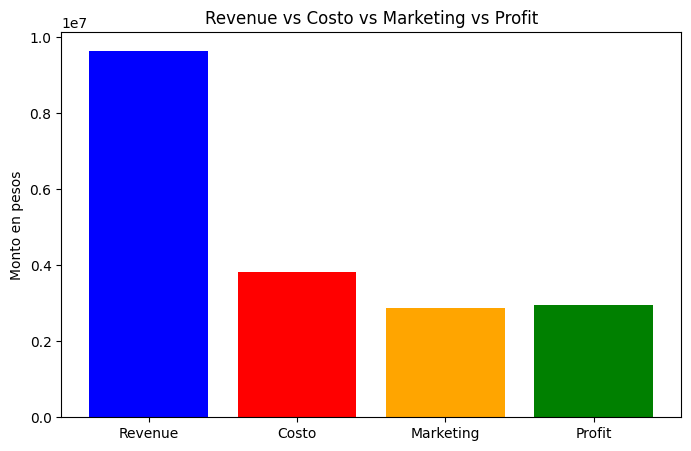

In [44]:
import matplotlib.pyplot as plt

# GRÁFICA 1: Rentabilidad 
# creamos una lista con los nombres y otra con los valores para graficarlos
nombres = ['Revenue', 'Costo', 'Marketing', 'Profit']
valores = [revenue_total, costo_total, marketing_total, profit]

plt.figure(figsize=(8,5))
plt.bar(nombres, valores, color=['blue','red','orange','green'])
plt.title('Revenue vs Costo vs Marketing vs Profit')
plt.ylabel('Monto en pesos')
plt.show()

Con esta gráfica podemos comparar el revenue (9.6 millones) contra los demás valores obtenidos. Se ve que el costo (3.8 millones) y el marketing (2.9 millones) son parecidos en tamaño, casi la misma altura de barra, entonces creo que ambos le "pesan" parecido al negocio. La barra de profit sale positiva (2.9 millones), entonces creo que sí se puede decir que el negocio es rentable.

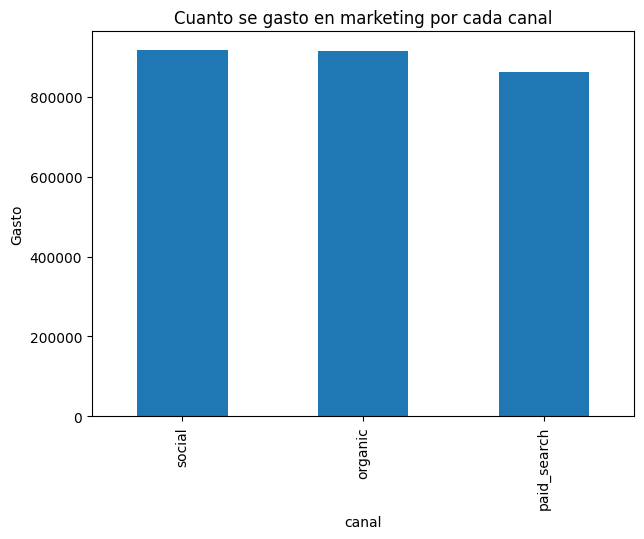

In [46]:
# gasto en marketing por canal
gasto_canal = marketing.groupby('canal')['gasto'].sum()
gasto_canal = gasto_canal.sort_values(ascending=False)

plt.figure(figsize=(7,5))
gasto_canal.plot(kind='bar')
plt.title('Cuanto se gasto en marketing por cada canal')
plt.ylabel('Gasto')
plt.show()

Aquí el objetivo es ver si algún canal de marketing se llevaba mucho más presupuesto que los otros, pero se ven bastante parecidos los tres (social, organic y paid_search), ninguno se ve muy por encima de los demás. No sé si esto es bueno o malo, porque nada más viendo el gasto no puedo saber cuál canal trae más resultados.

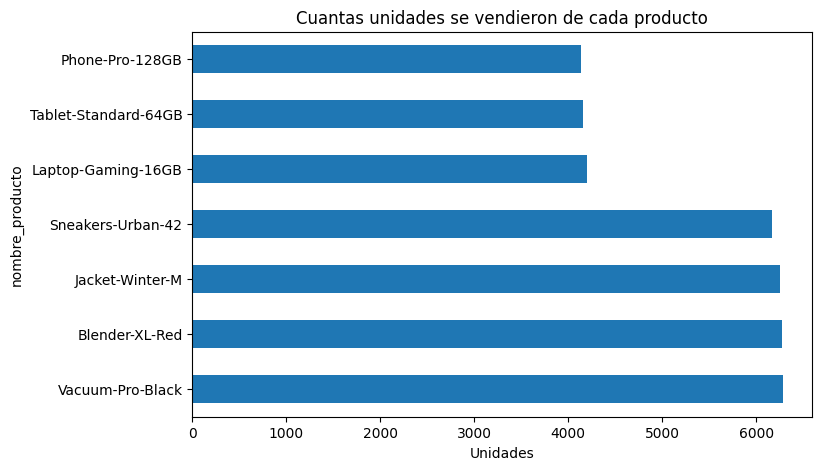

In [45]:
# agrupamos por producto y se suman las cantidades vendidas
ventas_producto = orders.groupby('nombre_producto')['cantidad'].sum()

# se ordena de mayor a menor para mejor presentación de la gráfica
ventas_producto = ventas_producto.sort_values(ascending=False)

plt.figure(figsize=(8,5))
ventas_producto.plot(kind='barh')
plt.title('Cuantas unidades se vendieron de cada producto')
plt.xlabel('Unidades')
plt.show()

Con esta gráfica se ve más claro que Vacuum-Pro-Black es el que más se vendió, aunque se puede ver que casi todos los productos de Hogar y Moda se venden igual (Blender, Jacket, Sneakers), no hay uno que se distinga mucho más que los demás. Lo que sí noté es que los 3 productos de electrónica (laptop, tablet, phone) vendieron mucho menos unidades que los otros 4. Hay la posibilidad que se deba a que su precio es mayor y por lo tanto la gente compra menos.

---

## 🔹 Paso 3: Entender dónde se pierden los usuarios (funnel de conversión)

**🎯 Objetivo:** Analizar el comportamiento de los usuarios para identificar en qué etapa del proceso se pierden.


⚙️**Conexión a la base de datos**:  
Se ejecuta la línea de configuración para conectar con la base de datos y aplicar consultas SQL en la tabla **events**.

---

**📊 Parte 1: Construcción del funnel**
- ¿Cuántos usuarios llegan a cada etapa del funnel?  
- Se calcula el número de usuarios únicos por `nombre_evento`  
- Se ordenan los eventos según el flujo del usuario  

---

**📉 Parte 2: Análisis de conversión**
- Se calcula la tasa de conversión entre cada paso del funnel  
- Se identifica en qué etapa se pierde la mayor cantidad de usuarios  
- ¿Cuál es la tasa de conversión final?
---

In [47]:
import pandas as pd
from sqlalchemy import create_engine

# ======================
# Conexión (NO modificar)
# ======================
db_config = {
    'user': 'practicum_student',
    'pwd': 'QnmDH8Sc2TQLvy2G3Vvh7',
    'host': 'yp-trainers-practicum.cluster-czs0gxyx2d8w.us-east-1.rds.amazonaws.com',
    'port': 5432,
    'db': 'data-analyst-production-db-en'
}

connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db']
)

engine = create_engine(connection_string, connect_args={'sslmode':'require'})

In [48]:
# Explorar tabla events
# =========================
query_events = '''
SELECT *
FROM events;
'''
events = pd.read_sql(query_events, con=engine)
events.head()

,id_usuario,id_sesion,nombre_evento,timestamp_evento,pais,dispositivo,fuente_referencia,categoria_producto
0,user_6772,6a97f2af-32ae-4186-8c92-04025be1a27b,first_visit,2025-05-17,Colombia,desktop,organic,Moda
1,user_5883,369b767c-1c33-4b2f-a652-c7c0ef92cfc9,add_to_cart,2025-02-23,Mexico,mobile,social,Hogar
2,user_5946,60039041-e78b-474c-87b3-c0b7e9c30708,add_payment_info,2025-05-15,Colombia,desktop,social,Electronica
3,user_827,18252a64-f389-4ef7-9e58-dadad4a3491e,purchase,2025-03-31,Mexico,mobile,social,Moda
4,user_2361,221b364e-cdc5-4668-b698-18d5ba849a67,first_visit,2025-01-22,Argentina,desktop,paid_search,Electronica


In [49]:
# PARTE 1: Totales del funnel
# ======================

query_totals = '''
SELECT
    nombre_evento,
    COUNT(DISTINCT id_usuario) AS usuarios_unicos,
    CASE nombre_evento
        WHEN 'first_visit' THEN 1
        WHEN 'select_item' THEN 2
        WHEN 'add_to_cart' THEN 3
        WHEN 'begin_checkout' THEN 4
        WHEN 'add_payment_info' THEN 5
        WHEN 'purchase' THEN 6
    END AS orden_funnel
FROM events
GROUP BY nombre_evento
ORDER BY orden_funnel;
'''

totals = pd.read_sql(query_totals, con=engine)
totals

,nombre_evento,usuarios_unicos,orden_funnel
0,first_visit,7796,1
1,select_item,7582,2
2,add_to_cart,7634,3
3,begin_checkout,7208,4
4,add_payment_info,6250,5
5,purchase,6240,6


In [50]:
# PARTE 2: Conversiones
# ======================

query_conversion = '''
WITH funnel AS (
    SELECT 
        nombre_evento,
        COUNT(DISTINCT id_usuario) AS usuarios_unicos,
        CASE nombre_evento
            WHEN 'first_visit' THEN 1
            WHEN 'select_item' THEN 2
            WHEN 'add_to_cart' THEN 3
            WHEN 'begin_checkout' THEN 4
            WHEN 'add_payment_info' THEN 5
            WHEN 'purchase' THEN 6
        END AS orden_funnel
    FROM events
    GROUP BY nombre_evento
)
SELECT 
    nombre_evento,
    usuarios_unicos,
    LAG(usuarios_unicos) OVER (ORDER BY orden_funnel) AS usuarios_paso_anterior,
    ROUND(100.0 * usuarios_unicos / LAG(usuarios_unicos) OVER (ORDER BY orden_funnel), 2) AS tasa_conversion_pct
FROM funnel
ORDER BY orden_funnel;
'''

conversion = pd.read_sql(query_conversion, con=engine)
conversion

,nombre_evento,usuarios_unicos,usuarios_paso_anterior,tasa_conversion_pct
0,first_visit,7796,NaN,NaN
1,select_item,7582,7796.0,97.26
2,add_to_cart,7634,7582.0,100.69
3,begin_checkout,7208,7634.0,94.42
4,add_payment_info,6250,7208.0,86.71
5,purchase,6240,6250.0,99.84


## Interpretación

Al ver la tabla de conversión, se puede notar que la caída más grande pasa entre begin_checkout y add_payment_info. Esto llama la atención porque es justo el paso donde el usuario tiene que meter sus datos de pago, lo que podría ser que el formulario sea muy largo, que sea complicado los métodos de pago disponibles, o que en ese momento no se decida si seguir. No tenemos forma de saber la razon exacta, pero sí podemos decir que es la etapa que más se debería revisar a detalle si se quiere subir la conversión total. También algo a destacar es que entre select_item y add_to_cart el número en realidad sube en vez de bajar (100.69%), lo cual no debería pasar en un funnel "normal" donde cada paso va bajando.

In [51]:
query_verificacion = '''
SELECT 
    COUNT(DISTINCT CASE WHEN nombre_evento = 'add_to_cart' THEN id_usuario END) AS usuarios_add_to_cart,
    COUNT(DISTINCT CASE WHEN nombre_evento = 'select_item' THEN id_usuario END) AS usuarios_select_item,
    COUNT(DISTINCT CASE WHEN nombre_evento = 'add_to_cart' AND id_usuario NOT IN (
        SELECT id_usuario FROM events WHERE nombre_evento = 'select_item'
    ) THEN id_usuario END) AS usuarios_add_to_cart_sin_select_item
FROM events;
'''
verificacion = pd.read_sql(query_verificacion, con=engine)
verificacion

,usuarios_add_to_cart,usuarios_select_item,usuarios_add_to_cart_sin_select_item
0,7634,7582,401


In [52]:
pct_sin_select_item = 401 / 7634 * 100
print(f"{pct_sin_select_item:.2f}% de los usuarios de add_to_cart no tuvieron select_item registrado")

5.25% de los usuarios de add_to_cart no tuvieron select_item registrado


El paso add_to_cart mostraba una conversión de 100.69% respecto a select_item porque no todos los usuarios que agregan un producto al carrito pasaron primero por un evento select_item registrado. Al verificar esto, se encontró que 401 usuarios llegaron a add_to_cart sin tener ningún select_item en su historial, esto representa el 5.25% de los usuarios de add_to_cart (401 de 7,634). Esto confirma que existe una ruta alterna dentro de la app que salta el evento de selección, y no un error en el cálculo del funnel ni en la consulta SQL.

In [53]:
query_conversion_total = '''
WITH funnel AS (
    SELECT 
        nombre_evento,
        COUNT(DISTINCT id_usuario) AS usuarios_unicos,
        CASE nombre_evento
            WHEN 'first_visit' THEN 1
            WHEN 'select_item' THEN 2
            WHEN 'add_to_cart' THEN 3
            WHEN 'begin_checkout' THEN 4
            WHEN 'add_payment_info' THEN 5
            WHEN 'purchase' THEN 6
        END AS orden_funnel
    FROM events
    GROUP BY nombre_evento
)
SELECT 
    nombre_evento,
    usuarios_unicos,
    ROUND(100.0 * usuarios_unicos / FIRST_VALUE(usuarios_unicos) OVER (ORDER BY orden_funnel), 2) AS conversion_total_pct
FROM funnel
ORDER BY orden_funnel;
'''
conversion_total = pd.read_sql(query_conversion_total, con=engine)
conversion_total

,nombre_evento,usuarios_unicos,conversion_total_pct
0,first_visit,7796,100.00
1,select_item,7582,97.26
2,add_to_cart,7634,97.92
3,begin_checkout,7208,92.46
4,add_payment_info,6250,80.17
5,purchase,6240,80.04


Se calculó la conversión total de cada etapa respecto al primer evento del funnel (first_visit). Esta vista es más clara porque nunca supera el 100%, ya que todas las etapas se comparan contra el mismo punto de partida. Con esta métrica se ve que el mayor desplome ocurre entre begin_checkout (92.46%) y add_payment_info (80.17%). La tasa de conversión final (purchase respecto a first_visit) es de 80.04%, es decir, 8 de cada 10 usuarios que visitan la app terminan completando una compra.

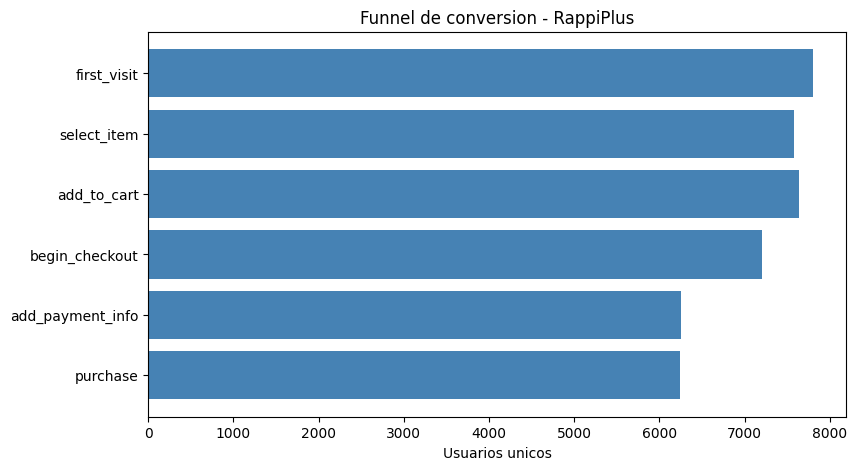

In [57]:
import matplotlib.pyplot as plt

import matplotlib.pyplot as plt

etapas = conversion_total['nombre_evento']
usuarios = conversion_total['usuarios_unicos']

plt.figure(figsize=(9,5))
plt.barh(etapas, usuarios, color='steelblue')
plt.title('Funnel de conversion - RappiPlus')
plt.xlabel('Usuarios unicos')
plt.gca().invert_yaxis() # ordena de mayor a menor
plt.show()

Esta gráfica permite ver de forma más visual cómo se va perdiendo gente en cada paso del funnel, en vez de solo ver la tabla de números. Hice uso de la IA para saber como poner el orden de mayor a menor porque cuando la hice por primera vez, first_visit me salía hasta abajo, entonces use **invert_yaxis()** con esa línea lo acomodé en el orden correcto. Se alcanza a ver que las barras van bajando de a poco, excepto en add_to_cart que se ve una minima diferencia que select_item, lo cual coincide con lo que ya había encontrado antes sobre que ese paso tiene un problema con cómo se registran los eventos.

---

## 🔹 Paso 4: Evaluar si los usuarios regresan (retención por cohortes)

**🎯 Objetivo:** Analizar la retención de usuarios para entender si regresan después de registrarse.

**Tablas**

- `users` 
- `user_activity` 

---
1. Se identifica la cohorte de cada usuario según el **mes de registro**.


2. Se calcula la retención semanal: cuántos usuarios **se mantienen activos** en cada semana desde su registro.
   - `retenido_w1`: usuarios activos en la semana 1  
   - `retenido_w2`: usuarios activos en la semana 2  
   - `retenido_w3`: usuarios activos en la semana 3  


3. Se calcula el porcentaje de retención para cada semana, dividiendo los usuarios retenidos entre los clientes iniciales de la cohorte:  
   - `semana_1`: porcentaje de usuarios retenidos en la semana 1  
   - `semana_2`: porcentaje de usuarios retenidos en la semana 2  
   - `semana_3`: porcentaje de usuarios retenidos en la semana 3  

Se revisa que la columna de fecha esté en formato correcto (`DATE`).  
Se realiza la conversión usando: `CAST(fecha_registro AS DATE)`

In [59]:
# Explorar tabla users
# =========================
query_users = '''
SELECT *
FROM users;
'''
users = pd.read_sql(query_users, con=engine)
users.head(3)

,id_usuario,fecha_registro,país,dispositivo,tipo_plan
0,user_0,2025-01-29,Mexico,mobile,free
1,user_1,2025-01-07,Mexico,mobile,free
2,user_2,2025-03-12,Argentina,mobile,free


In [60]:
# Explorar tabla user_activity
# =========================
query_user_activity = '''
SELECT *
FROM user_activity;
'''
user_activity = pd.read_sql(query_user_activity, con=engine)
user_activity.head(3)

,id_usuario,fecha_actividad,dias_despues_registro,activo
0,user_0,2025-02-05,7,0
1,user_0,2025-02-12,14,1
2,user_0,2025-02-19,21,1


In [61]:
# Retención por cohortes
# ======================

query_cohort_retention_final = '''
WITH cohortes AS (
    SELECT
        id_usuario,
        DATE_TRUNC('month', CAST(fecha_registro AS DATE)) AS mes_cohorte 
    FROM users
),
tamanio_cohorte AS (
    SELECT 
        mes_cohorte,
        COUNT(DISTINCT id_usuario) As usuarios_iniciales
    FROM cohortes
    GROUP BY mes_cohorte
),
retencion_semanal AS(
    SELECT 
        c.mes_cohorte,
        ua.dias_despues_registro / 7 AS semana,
        COUNT(DISTINCT CASE WHEN ua.activo = 1 THEN ua.id_usuario END) AS usuarios_retenidos
    FROM user_activity ua
    JOIN cohortes c ON ua.id_usuario = c.id_usuario
    WHERE ua.dias_despues_registro IN (7, 14, 21)
    GROUP BY c.mes_cohorte, ua.dias_despues_registro / 7
)
SELECT
    r.mes_cohorte,
    t.usuarios_iniciales,
    MAX(CASE WHEN r.semana = 1 THEN r.usuarios_retenidos END) AS retenido_w1,
    MAX(CASE WHEN r.semana = 2 THEN r.usuarios_retenidos END) AS retenido_w2,
    MAX(CASE WHEN r.semana = 3 THEN r.usuarios_retenidos END) AS retenido_w3,

    ROUND(100.0 * MAX(CASE WHEN r.semana = 1 THEN r.usuarios_retenidos END) / t.usuarios_iniciales, 2) AS semana_1,
    ROUND(100.0 * MAX(CASE WHEN r.semana = 2 THEN r.usuarios_retenidos END) / t.usuarios_iniciales, 2) AS semana_2,
    ROUND(100.0 * MAX(CASE WHEN r.semana = 3 THEN r.usuarios_retenidos END) / t.usuarios_iniciales, 2) AS semana_3
    FROM retencion_semanal r
    JOIN tamanio_cohorte t ON r.mes_cohorte = t.mes_cohorte
    GROUP BY r.mes_cohorte, t.usuarios_iniciales
    ORDER BY r.mes_cohorte;
'''

# Ejecutar la consulta
cohorte_final = pd.read_sql(query_cohort_retention_final, con=engine)
cohorte_final

,mes_cohorte,usuarios_iniciales,retenido_w1,retenido_w2,retenido_w3,semana_1,semana_2,semana_3
0,2025-01-01 00:00:00+00:00,1627,697,668,656,42.84,41.06,40.32
1,2025-02-01 00:00:00+00:00,1444,611,609,635,42.31,42.17,43.98
2,2025-03-01 00:00:00+00:00,1636,677,705,690,41.38,43.09,42.18
3,2025-04-01 00:00:00+00:00,1606,680,697,663,42.34,43.40,41.28
4,2025-05-01 00:00:00+00:00,1687,695,676,706,41.20,40.07,41.85


Aquí hay algo que vale la pena señalar antes de sacar conclusiones de negocio. La retención se comporta distinto a lo que normalmente se podría esperar.
Los datos muestran que los porcentajes se mantienen bastante planos, entre 40-44%, y en varias cohortes suben en lugar de bajar:

Febrero: 1er semana (42.31%), 2da semana (42.17%) 3er semana (43.98%), tiene una tendencia plana y al final alcista
Marzo: 1er semana (41.38%), 2da semana (43.09%), 3er semana (42.18%), primero sube y luego baja

Al ver los resultados, se esperaba que el porcentaje de retención bajara conforme pasaban las semanas, pero en varias cohortes se mantiene en rangos similares o suben para la semana 3. Esto sugiere que la columna "activo" no representa una retención de verdad, pareciera que cada semana se calculó como si fuera independiente de las anteriores. 

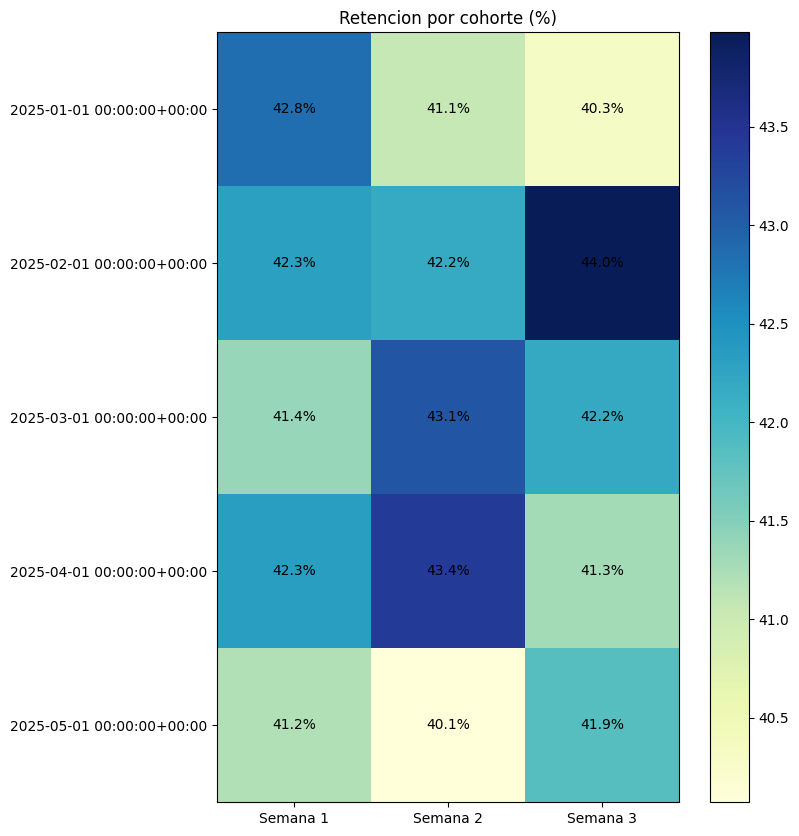

In [66]:
import matplotlib.pyplot as plt

matriz = cohorte_final[['semana_1', 'semana_2', 'semana_3']].values

plt.figure(figsize=(8,10))
plt.imshow(matriz, cmap='YlGnBu')

# lnombres a los ejes para que se entienda
plt.xticks([0,1,2], ['Semana 1', 'Semana 2', 'Semana 3'])
plt.yticks(range(len(cohorte_final)), cohorte_final['mes_cohorte'])
plt.title('Retencion por cohorte (%)')
plt.colorbar()

# esto lo agregue para poder ver el numero exacto en cada cuadrito, si no solo se ve el color
for i in range(matriz.shape[0]):
    for j in range(matriz.shape[1]):
        plt.text(j, i, f'{matriz[i,j]:.1f}%', ha='center', va='center')

plt.show()

Este heatmap nos ayuda a ver de forma más visual cómo se comporta la retención de cada cohorte en las 3 semanas. Esperaba ver un patrón más claro, es decir, que los colores se fueran aclarando de la semana 1 a la semana 3 (cada vez menos gente siga activa), pero no es lo que se observa, los colores están como revueltos sin ningún orden. Esto confirma lo que ya habíamos visto antes, que la retención se mantiene casi plana (entre 40% y 44%) sin importar si ya pasaron 1, 2 o 3 semanas desde que la persona se registró. 

---

## 🔹 Paso 5: Validar si los cambios generan impacto (test estadístico)

🎯 **Objetivo:** Evaluar si la modificación en la UI del checkout impacta la **tasa de conversión de compra**.

---

1. **Analizar el dataset** `experiment_checkout_ui.csv` para identificar la métrica principal **conversion**.
   - La métrica **conversion** es 1 si el usuario completó la compra, 0 si no.    
2. **Plantear la hipótesis estadística**     
3. **Aplicar el test estadístico adecuado**
4. **Interpretar el resultado**

---
Hipótesis estadística
   - **H₀ (Hipótesis nula):** no hay diferencia en la tasa de conversión entre el checkout original y el nuevo diseño.
   - **H₁ (Hipótesis alternativa):** sí hay una diferencia en la tasa de conversión entre ambos grupos
   
**Test estadístico:**  
**Nivel de significancia alpha:** α = 0.05

In [42]:
# Exploramos el dataset
prueba = pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/experiment_checkout_ui.csv')
prueba.head(5)

,id_usuario,variante,convirtio,dispositivo,pais,duracion_sesion,timestamp
0,exp_user_0,tratamiento,0,mobile,Argentina,114.41,2025-03-28
1,exp_user_1,tratamiento,0,desktop,Mexico,170.03,2025-01-15
2,exp_user_2,control,1,mobile,Colombia,140.21,2025-03-18
3,exp_user_3,tratamiento,0,mobile,Colombia,151.45,2025-06-03
4,exp_user_4,tratamiento,0,desktop,Mexico,299.96,2025-01-12


In [43]:
prueba.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id_usuario       10000 non-null  object 
 1   variante         10000 non-null  object 
 2   convirtio        10000 non-null  int64  
 3   dispositivo      10000 non-null  object 
 4   pais             10000 non-null  object 
 5   duracion_sesion  10000 non-null  float64
 6   timestamp        10000 non-null  object 
dtypes: float64(1), int64(1), object(5)
memory usage: 547.0+ KB


In [44]:
prueba['convirtio'].value_counts()

0    8401
1    1599
Name: convirtio, dtype: int64

In [45]:
# Aplicamos el test
# Importamos libreria
from statsmodels.stats.proportion import proportions_ztest

# Conteos y totales por grupo
conversiones_control = prueba[prueba['variante'] == 'control']['convirtio'].sum()
n_control = len(prueba[prueba['variante'] == 'control'])

conversiones_tratamiento = prueba[prueba['variante'] == 'tratamiento']['convirtio'].sum()
n_tratamiento = len(prueba[prueba['variante'] == 'tratamiento'])

conteos = [conversiones_control, conversiones_tratamiento]
totales = [n_control, n_tratamiento]

z_stat, p_value = proportions_ztest(conteos, totales)

print(f"Tasa control: {conversiones_control/n_control*100:.2f}%")
print(f"Tasa variante: {conversiones_tratamiento/n_tratamiento*100:.2f}%")
print(f"Estadístico Z: {z_stat:.4f}")
print(f"P-value: {p_value:.4f}")

alpha = 0.05
if p_value < alpha:
    print("Se rechaza la hipótesis nula: hay diferencia estadísticamente significativa")
else:
    print("No se rechaza la hipótesis nula: no hay evidencia suficiente de diferencia")

Tasa control: 15.69%
Tasa variante: 16.29%
Estadístico Z: -0.8133
P-value: 0.4161
No se rechaza la hipótesis nula: no hay evidencia suficiente de diferencia


No hay evidencia estadística de que el nuevo diseño del checkout mejore la tasa de conversión. Esto no quiere decir necesariamente que el nuevo diseño sea "igual de bueno" o "malo", solo que con los datos que tenemos, no podemos afirmar con certeza que haya una diferencia real. Antes de decidir implementar el cambio permanentemente basándose en esta mejora observada.

---

## 🔹 Paso 6: Comunicar los resultados (Dashboard en BI)

🎯 **Objetivo**:  
Crear un dashboard que muestre de manera clara y visual los resultados del análisis de ventas, costos, marketing y conversión. 

Se usarán los CSVs limpios del Paso 1:

- `orders_clean.csv`  
- `catalog_clean.csv`  
- `marketing_clean.csv`
---

1️⃣ Preparación de los datos
1. Cargar los CSVs en Power BI o Tableau.
2. Revisar relaciones:
   - `orders.nombre_producto` → `catalog.nombre_producto`
   - `orders.fecha_pedido` → tabla de fechas (crear calendario para análisis temporal)
   - `orders.fecha_pedido` → `dim_fecha.date`
3. Crear columnas calculadas necesarias
4. Crear tabla de fechas para poder calcular comparaciones YTD, YoY o períodos anteriores (`Previous Year`, `Previous Month`).

---

2️⃣ Dashboard 1: Overview Ejecutivo
**KPIs principales a mostrar:**
- Revenue total
- Profit total
- Gasto total en marketing
- Ticket promedio
- Cantidad promedio de productos por orden

**Visualizaciones sugeridas:**
- Tarjetas KPI para revenue, profit y gasto marketing
- Gráfico de líneas: evolución mensual de revenue o profit
- Gráfico de líneas YTD
- Gráfico de barras: revenue y profit por producto o categoría

---

 3️⃣ Dashboard 2: Detalle / Drill-through  
**Objetivo:** Permitir explorar los datos desde el KPI general hasta cada orden o producto.

**Visualizaciones sugeridas:**
- Tabla detallada de órdenes con:
  - producto, cantidad, revenue, cost, profit
  - color condicional (profit negativo en rojo, positivo en verde)
- Gráfico de barras por producto con medida `cantidad vendida`
- Drill-through: seleccionar un producto y ver todos los pedidos relacionados
- Filtros por fecha, categoría de producto, etc


### **NOTA**
Se intentó implementar drill-through por producto, sin embargo, la versión de Power BI Desktop utilizada presenta el panel de filtros en su formato moderno, donde la configuración de drill-through no se ubicó en la interfaz. Se decidió priorizar la funcionalidad principal del dashboard (KPIs, gráficos, filtros) sobre esta función.

# **Conclusiones y recomendaciones generales**

### Calidad de los datos (Paso 1)

Al revisar los tres datasets encontré varios problemas que tuve que limpiar antes de poder confiar en los números: pedidos con cantidad negativa, algunos con cantidades absurdamente grandes (10,000 y 20,000 unidades), 100 filas duplicadas exactas, y varias inconsistencias de formato (mayúsculas y acentos) que hubieran hecho fallar los cruces entre tablas más adelante. También encontré 50 filas con varios campos nulos (cantidad, precio, descuento) que decidí no eliminar porque igual tenían el monto_total completo. En general, aunque los problemas no eran muchos en proporción al total de datos, sí eran del tipo que pueden pasar desapercibidos si no se revisan a fondo antes de analizar.

### Rentabilidad del negocio (Paso 2)

El negocio sí es rentable: con un revenue de 9.64 millones, un costo de producto de 3.83 millones y una inversión en marketing de 2.87 millones, queda un profit de 2.94 millones, o sea un margen de rentabilidad de aproximadamente 30.5%. El ticket promedio es de $385.97 por pedido, con un promedio de 1.5 productos por orden. Vacuum-Pro-Black es el producto más vendido tanto en unidades como en revenue. Un hallazgo que me pareció importante es que Laptop-Gaming-16GB es el único producto con margen bruto negativo, lo que quiere decir que actualmente le cuesta dinero al negocio en vez de generarle ganancia.

### Funnel de conversión (Paso 3)

De cada 100 usuarios que entran a la app, 80 terminan comprando (80.04% de conversión final), lo cual es una tasa bastante alta, aunque probablemente se explica porque estos usuarios ya son clientes de RappiPlus y no visitantes nuevos. El mayor punto de fuga está entre begin_checkout y add_payment_info, es la etapa que más se debería revisar para mejorar la conversión total.

### Retención de usuarios (Paso 4)

A diferencia de lo que esperaba, la retención no muestra una caída progresiva típica: se mantiene bastante plana entre 40% y 44% en las 3 semanas revisadas, sin importar la cohorte. Esto me hace pensar que puede ser una limitación de cómo está armada la columna "activo" en los datos, más que un reflejo real del comportamiento de los usuarios.

### Test estadístico (Paso 5)

Aunque el nuevo diseño de checkout mostró una tasa de conversión un poco más alta que el original (16.29% vs 15.69%), el test estadístico (p-value = 0.4161) no encontró evidencia suficiente para decir que esa diferencia es real y no producto del azar. Por ahora no recomendaría implementar el cambio basándose solo en este resultado.

### Dashboard (Paso 6)

Se construyeron dos dashboards en Power BI: uno ejecutivo con los KPIs principales de rentabilidad y ventas, y uno de detalle que permite explorar las órdenes por producto con indicador visual de rentabilidad (verde/rojo).

### Recomendaciones para la empresa
* Revisar el margen negativo de Laptop-Gaming-16GB, ya sea ajustando su precio, renegociando el costo con el proveedor, o evaluando si vale la pena seguir vendiéndolo en las condiciones actuales.
* Investigar la fricción en el paso de pago (add_payment_info), es el cuello de botella más grande del funnel, valdría la pena revisar el formulario de pago o los métodos disponibles.
* No implementar el nuevo diseño de checkout todavía, el test no mostró una mejora estadísticamente significativa, se podría probar con una muestra más grande o un cambio de diseño antes de tomar una decisión.

---

### 📎 Enlace del Dashboard

In [47]:
# https://drive.google.com/drive/folders/19FhZiG65pjKChRDKX-zGs1VtOcznf9Ng?usp=sharing